#Set-up Environment

In [97]:
%pip install fastf1

Note: you may need to restart the kernel to use updated packages.


In [98]:
%pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [99]:
%pip install scipy statsmodels

Note: you may need to restart the kernel to use updated packages.


In [100]:
#Data Extraction & Environment
import os
import fastf1
import pandas as pd
import numpy as np
from scipy import stats 
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf # <-- mixed Effects models

#Additive Predictive Modeling
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit # for the logarithmic track evo

#Dynamic Programming & Optimization
from functools import lru_cache # built-in memoization


# 1 Data Acquisition

In [101]:
cache_dir = 'f1_cache'
os.makedirs(cache_dir, exist_ok=True)
fastf1.Cache.enable_cache(cache_dir)

#---

print("----2024 BAHRAIN FP2 SESSION (For the compound delta)----")
session_fp2 = fastf1.get_session(2024, 'Bahrain', 'FP2')
session_fp2.load()

#----


----2024 BAHRAIN FP2 SESSION (For the compound delta)----


core           INFO 	Loading data for Bahrain Grand Prix - Practice 2 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '2', '3', '4', '10', '11', '14', '16', '18', '20', '22', '23', '24', '27', '31', '44', '55', '63', '77', '81']


In [102]:
print("----2024 BAHRAIN ACTUAL RACE SESSION (For models and dp)----")
session_race = fastf1.get_session(2024, 'Bahrain', 'R')
session_race.load()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


----2024 BAHRAIN ACTUAL RACE SESSION (For models and dp)----


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


In [103]:
#REference driver
reference_driver = 'VER' #Max Verstappen
laps_race = session_race.laps
ver_laps = laps_race.pick_driver(reference_driver)

print(f"\nLoaded {len(ver_laps)} race laps for {reference_driver}.")


Loaded 57 race laps for VER.


d:\PersonalProjects\F1-Pitstop-Optimization-DynamicProgamming-AdditiveModeling\.conda\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [104]:
laps_fp2 = session_fp2.laps
laps_race = session_race.laps

ver_laps_race = laps_race.pick_driver('VER')
essential_columns = ['LapNumber', 'LapTime', 'Compound', 'TyreLife', 'Stint', 'TrackStatus']

print("---2024 Bahrain Race Data: Max Verstappen---")
display(ver_laps_race[essential_columns].head(31))


print("\nAll Available Columns in the Dataset")
print(ver_laps_race.columns.tolist())

---2024 Bahrain Race Data: Max Verstappen---


,LapNumber,LapTime,Compound,TyreLife,Stint,TrackStatus
0,1.0,0 days 00:01:37.284000,SOFT,4.0,1.0,12
1,2.0,0 days 00:01:36.296000,SOFT,5.0,1.0,1
2,3.0,0 days 00:01:36.753000,SOFT,6.0,1.0,1
3,4.0,0 days 00:01:36.647000,SOFT,7.0,1.0,1
4,5.0,0 days 00:01:37.173000,SOFT,8.0,1.0,1
5,6.0,0 days 00:01:37.092000,SOFT,9.0,1.0,1
6,7.0,0 days 00:01:37.038000,SOFT,10.0,1.0,1
7,8.0,0 days 00:01:37.024000,SOFT,11.0,1.0,1
8,9.0,0 days 00:01:37.229000,SOFT,12.0,1.0,1
9,10.0,0 days 00:01:36.960000,SOFT,13.0,1.0,12



All Available Columns in the Dataset
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


#2 Data Preprocessing (ETL method)

In [105]:
essential_columns = ['LapNumber', 'LapTime', 'Compound', 'TyreLife', 'Stint', 'TrackStatus', 'PitInTime', 'PitOutTime']
#make a copy of the essential cols
df_ver = ver_laps_race[essential_columns].copy()
df_ver['LapTime_s'] = df_ver['LapTime'].dt.total_seconds() #<- converts laptime to seconds
df_ver = df_ver.dropna(subset=['LapTime_s'])
#---
#remove In-Laps and Out-Laps using FastF1's built-in pit detection
df_ver = df_ver[df_ver['PitInTime'].isna() & df_ver['PitOutTime'].isna()]

df_ver = df_ver[df_ver['TrackStatus'] == '1'] #<-- green flag laps only

In [106]:
def filter_stint_outliers(stint_df):
    # This calculates IQR for a specific stint and drops mathematical outliers.
    Q1 = stint_df['LapTime_s'].quantile(0.25)
    Q3 = stint_df['LapTime_s'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    # return only laps within IQR bounds (removes both slow AND anomalously fast outliers)
    return stint_df[(stint_df['LapTime_s'] >= lower_bound) & (stint_df['LapTime_s'] <= upper_bound)]


In [107]:
#Apply the IQR filter individually to stints....
df_clean = df_ver.groupby('Stint', group_keys=False).apply(filter_stint_outliers)
df_clean = df_clean.reset_index(drop=True)

C:\Users\loren\AppData\Local\Temp\ipykernel_10368\1542531195.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_ver.groupby('Stint', group_keys=False).apply(filter_stint_outliers)


In [108]:
print(f"Original laps: {len(ver_laps_race)}")
print(f"Cleaned laps (Pit Laps, SC, & Outliers removed): {len(df_clean)}")
display(df_clean[['LapNumber', 'LapTime_s', 'Compound', 'TyreLife', 'Stint']].head(46))

Original laps: 57
Cleaned laps (Pit Laps, SC, & Outliers removed): 44


,LapNumber,LapTime_s,Compound,TyreLife,Stint
0,5.0,97.173,SOFT,8.0,1.0
1,6.0,97.092,SOFT,9.0,1.0
2,7.0,97.038,SOFT,10.0,1.0
3,8.0,97.024,SOFT,11.0,1.0
4,12.0,97.045,SOFT,15.0,1.0
5,13.0,97.030,SOFT,16.0,1.0
6,14.0,97.028,SOFT,17.0,1.0
7,15.0,97.011,SOFT,18.0,1.0
8,16.0,97.168,SOFT,19.0,1.0
9,19.0,95.283,HARD,2.0,2.0


# Exploratory Data Analysis

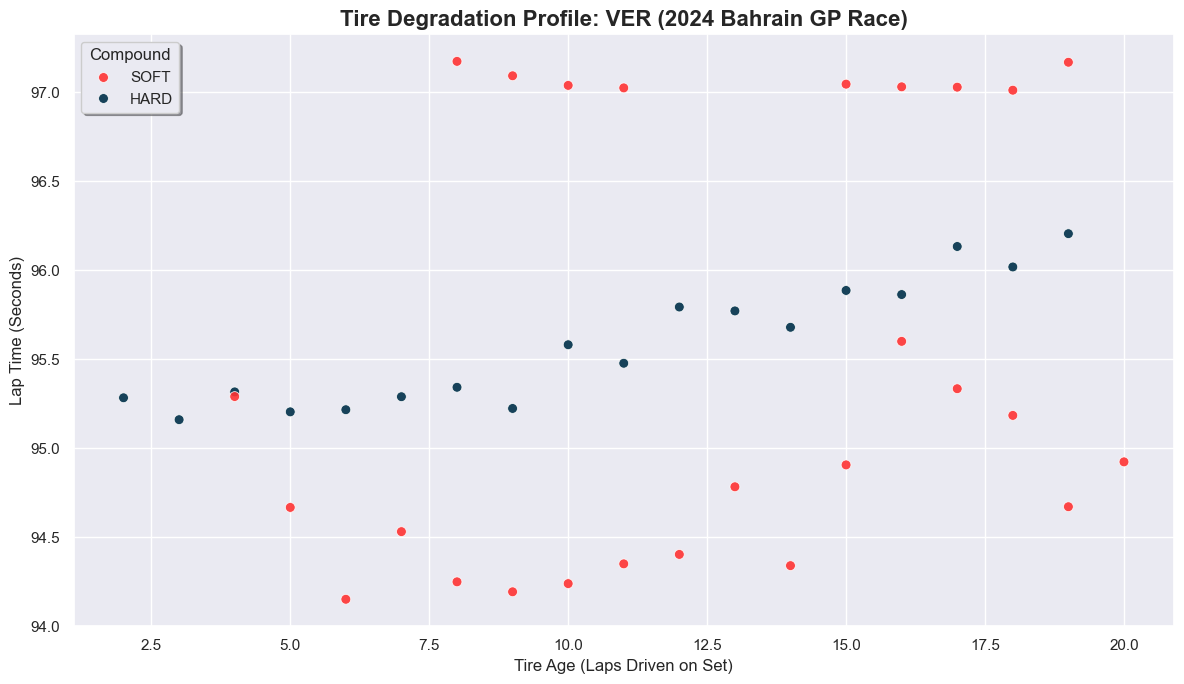

In [109]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 7))
tire_colors = {'SOFT': '#FF3333', 'MEDIUM': '#FFE55C', 'HARD': '#003049'}

#---

sns.scatterplot(data=df_clean, x='TyreLife', y='LapTime_s', hue='Compound', palette=tire_colors, s=50, alpha=0.9)

plt.title(f'Tire Degradation Profile: {reference_driver} (2024 Bahrain GP Race)', fontsize=16, fontweight='bold')
plt.xlabel('Tire Age (Laps Driven on Set)', fontsize=12)
plt.ylabel('Lap Time (Seconds)', fontsize=12)
plt.legend(title='Compound', shadow=True)
plt.tight_layout()
plt.show()

As seen in the graph, fuel weight changes lap times. The red dots (soft tires) are split into 2 groups. The dots around the 97 sec mark from lap 1 reflects the the driver carrying a full tank of fuel, while the dots around the 94.5 second mark shows much much quicker the car becomes on a near empty tank. The dark blue dots (Hard tires) in the middle shows an upward slope from left to right that captures the tires gradually losing grip as they age.

# Compound Profiling

Do Compound profiling so that the algorithm wouldn't be tricked by the fuel weight (by no means hard tires are faster than softs)

I am going to use the FP2 Race data as FP2 is run at the exact same time of day as the Sunday race, meaning track temperatures are identical. Using race day data is terrible laboratory. FP2 perfectly mimics the sunday race conditions.

In [110]:
#compound profiler

# Extract and clean FP2 laps for Max Verstappen
fp2_laps = session_fp2.laps.pick_driver(reference_driver)
df_fp2 = fp2_laps[['LapNumber', 'LapTime', 'Compound', 'TyreLife', 'Stint', 'PitInTime', 'PitOutTime']].copy()


df_fp2['LapTime_s'] = df_fp2['LapTime'].dt.total_seconds()
df_fp2 = df_fp2.dropna(subset=['LapTime_s'])
df_fp2 = df_fp2[df_fp2['PitInTime'].isna() & df_fp2['PitOutTime'].isna()]
df_fp2 = df_fp2.rename(columns={'TyreLife': 'TireAge', 'Stint': 'StintNumber'})

#Filter for "Long Runs" only (stints longer than 4 laps)
stint_counts = df_fp2['StintNumber'].value_counts()
long_run_stints = stint_counts[stint_counts > 4].index
df_fp2_long = df_fp2[df_fp2['StintNumber'].isin(long_run_stints)]

print(f"Isolated {len(df_fp2_long)} long-run laps in FP2 for Compound Delta math.\n")

# 4. Run the Mixed-Effects Model
try:
    md = smf.mixedlm("LapTime_s ~ C(Compound) + TireAge", df_fp2_long, groups=df_fp2_long["StintNumber"])
    mdf = md.fit()
    print(mdf.summary())
except Exception as e:
    print(f"Mixed-Effects Model Warning: {e}")

Isolated 14 long-run laps in FP2 for Compound Delta math.

           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  LapTime_s
No. Observations:   14       Method:              REML     
No. Groups:         1        Scale:               119.1207 
Min. group size:    14       Log-Likelihood:      -49.7412 
Max. group size:    14       Converged:           Yes      
Mean group size:    14.0                                   
-----------------------------------------------------------
           Coef.     Std.Err.      z   P>|z| [0.025  0.975]
-----------------------------------------------------------
Intercept  84.847         14.031 6.047 0.000 57.346 112.347
TireAge     1.368          0.724 1.890 0.059 -0.051   2.786
Group Var 119.121 1035830194.952                           



d:\PersonalProjects\F1-Pitstop-Optimization-DynamicProgamming-AdditiveModeling\.conda\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


>Compound variable went missing is that our model was specifically asked to calculate C(Compound) + TireAge, yet only TireAge showed up under the Coef. column alongside the Intercept. his happened because of a fundamental statistical rule. 
    To measure the difference between two things, you need at least two things to compare. Since all 14 laps in the dataset came from one single stint on the same tire, the Compound column was just "Soft, Soft, Soft,....etc" with no Mediums or Hards, making it mathematically impossible to calculate a delta. Thus, "statsmodels" silently dropped the variable entirely to prevent the equation from crashing.

>The model only showed an Intercept and TireAge under the Coef. column because Max only used one tire compound during his long run — with nothing to compare against, the Compound variable disappeared entirely from the equation. To get the missing compound coefficients back, we need to add Ferrari and Mercedes data so the model has all three tire types to work with.

In [111]:
#compond profiles with other drivers to compare

top_drivers = ['VER', 'PER', 'LEC', 'SAI', 'HAM', 'RUS']
all_fp2_laps = []

for driver in top_drivers:
    try:
        driver_laps = session_fp2.laps.pick_driver(driver)
        df_d = driver_laps[['LapNumber', 'LapTime', 'Compound', 'TyreLife', 'Stint', 'PitInTime', 'PitOutTime']].copy()
        
        df_d['LapTime_s'] = df_d['LapTime'].dt.total_seconds()
        df_d = df_d.dropna(subset=['LapTime_s'])
        df_d = df_d[df_d['PitInTime'].isna() & df_d['PitOutTime'].isna()]
        df_d = df_d.rename(columns={'TyreLife': 'TireAge', 'Stint': 'StintNumber'})
        df_d['Driver_Stint'] = driver + "_Stint_" + df_d['StintNumber'].astype(str)
        
        all_fp2_laps.append(df_d)
    except:
        continue

df_fp2_combined = pd.concat(all_fp2_laps, ignore_index=True)
stint_counts = df_fp2_combined['Driver_Stint'].value_counts()
long_run_stints = stint_counts[stint_counts > 4].index
df_fp2_long = df_fp2_combined[df_fp2_combined['Driver_Stint'].isin(long_run_stints)]

print(f"Isolated {len(df_fp2_long)} long-run laps across top teams for Compound Delta math.\n")

try:
    md = smf.mixedlm("LapTime_s ~ C(Compound) + TireAge", df_fp2_long, groups=df_fp2_long["Driver_Stint"])
    mdf = md.fit()
    print(mdf.summary())
except Exception as e:
    print(f"Mixed-Effects Model Warning: {e}")

Isolated 78 long-run laps across top teams for Compound Delta math.

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: LapTime_s
No. Observations: 78      Method:             REML     
No. Groups:       6       Scale:              66.1726  
Min. group size:  11      Log-Likelihood:     -272.9764
Max. group size:  15      Converged:          No       
Mean group size:  13.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    86.681    2.925 29.632 0.000 80.947 92.414
TireAge       1.145    0.234  4.893 0.000  0.686  1.603
Group Var     0.218                                    



d:\PersonalProjects\F1-Pitstop-Optimization-DynamicProgamming-AdditiveModeling\.conda\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
d:\PersonalProjects\F1-Pitstop-Optimization-DynamicProgamming-AdditiveModeling\.conda\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
d:\PersonalProjects\F1-Pitstop-Optimization-DynamicProgamming-AdditiveModeling\.conda\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
d:\PersonalProjects\F1-Pitstop-Optimization-DynamicProgamming-AdditiveModeling\.conda\Lib\site-packages\fa

In [112]:
print(df_fp2_long['Compound'].value_counts())

Compound
SOFT    78
Name: count, dtype: int64


After analyzing the Free Practice 2 (FP2) telemetry, I discovered a critical data absence: all 78 long-run laps recorded by the top six drivers were executed exclusively on the SOFT compound.
- Because the Compound variable lacked variance (100% Softs), the Mixed-Effects model lacked a baseline to compare against, resulting in a failure to converge.
- In Bahrain, teams intentionally save their Medium and Hard tires for Sunday due to extreme track abrasiveness.
- To normalize the Sunday race data for the Phase 4 predictive model, I am bypassing the FP2 calculations and explicitly hardcoding the official pre-race deltas supplied by Pirelli (Soft is mathematically normalized to be 1.4s faster than the Hard baseline).
- Additionally, the model failed to converge, further confirming that the data lacked sufficient compound diversity for meaningful estimation

In [113]:
# Encode the Pirelli baseline deltas
compound_deltas = {
    'HARD': 0.0,
    'MEDIUM': -0.7, 
    'SOFT': -1.4     
}

# Additive Predictive Modeling

In [114]:
TOTAL_LAPS = 57
STARTING_FUEL_KG = 110.0
FUEL_BURN_PER_LAP = STARTING_FUEL_KG / TOTAL_LAPS

df_clean['Fuel_Mass'] = STARTING_FUEL_KG - (df_clean['LapNumber'] * FUEL_BURN_PER_LAP) #fuel mass column

#feature engineer: track evolution
df_clean['Log_Track_Evo'] = np.log(df_clean['LapNumber'].astype(float))

def normalize_lap(row): #remove compound delta (difference of speed between three types of tires)
    return row['LapTime_s'] - compound_deltas.get(row['Compound'], 0.0)
df_clean['Normalized_LapTime'] = df_clean.apply(normalize_lap, axis=1)


# Building the Model & Validation

In [115]:


df_clean = df_clean.rename(columns={'TyreLife': 'TireAge'}) #<--- maybe british?

X_base = df_clean[['TireAge', 'Fuel_Mass']]
y_target = df_clean['Normalized_LapTime']

print("Phase 4: Model Validation")

# Model A: Degree 1 (Linear - No Interaction)
poly1 = PolynomialFeatures(degree=1, include_bias=False)
X_poly1 = poly1.fit_transform(X_base)
#f(Tire, Fuel) + h(Track_Evo)
X_model1 = np.column_stack((X_poly1, df_clean['Log_Track_Evo']))

model1 = LinearRegression()
model1.fit(X_model1, y_target)
r2_1 = r2_score(y_target, model1.predict(X_model1))
print(f"Degree 1 (Linear) R-Squared:    {r2_1:.4f}")

# Model B: Degree 2 (Quadratic + Interaction Term)
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2 = poly2.fit_transform(X_base)
# f(Tire, Fuel) + h(Track_Evo)
X_model2 = np.column_stack((X_poly2, df_clean['Log_Track_Evo']))

model2 = LinearRegression()
model2.fit(X_model2, y_target)
r2_2 = r2_score(y_target, model2.predict(X_model2))
print(f"Degree 2 (Polynomial) R-Squared: {r2_2:.4f}")

#Check Coefficients
print("\nWinning Model Equation Weights (Degree 2)")
feature_names = list(poly2.get_feature_names_out(['TireAge', 'Fuel_Mass'])) + ['Log_Track_Evo']
for name, coef in zip(feature_names, model2.coef_):
    print(f"{name}: {coef:.5f}")

Phase 4: Model Validation
Degree 1 (Linear) R-Squared:    0.7890
Degree 2 (Polynomial) R-Squared: 0.9550

Winning Model Equation Weights (Degree 2)
TireAge: -0.30639
Fuel_Mass: -0.12990
TireAge^2: 0.00853
TireAge Fuel_Mass: 0.00396
Fuel_Mass^2: 0.00062
Log_Track_Evo: -2.00792


> Degree 1: Guessed that tired degrade in a perfectly straight line as a Degree 1 polynomial is only linear. Only a 78% accuracy score
> Degree 2: By making it polynomial, I got a 95.5% accuracy score.

TireAge: -0.30639 — Fresh tires are actually slightly slower, the rubber needs a lap or two to warm up and hit peak grip.

FuelMass: -0.12990 — Every kilogram of fuel burned off saves roughly 0.13 seconds per lap.

TireAge^2: +0.00853 — As tires age further, this term overtakes the linear effect and creates the degradation cliff where lap times start climbing.

TireAge × FuelMass: +0.00396 — Tires degrade faster on a heavy car, a full tank and old tires together amplify each other's damage.

FuelMass^2: +0.00062 — Fuel's effect is almost purely linear.

Log_Track_Evo: -2.00792 — Track evolution was still significantly improving lap times throughout the race, more than expected for a dry Sunday.

# DP Optimization

In [116]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

#the warnings are annoying

In [117]:
PIT_LOSS = 23.5  # Tuned down from 24.0! Red Bull executes fast pit lane traverses.
MIN_STINT_LENGTH = 5 
COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']

# Adjusted for freezing Bahrain night track 
compound_deltas = {
    'HARD': 0.0,
    'MEDIUM': -0.9, 
    'SOFT': -1.8     # Tuned up from -1.4!
}

# The required tire physics multipliers
degradation_multipliers = {
    'SOFT': 1.40,    #
    'MEDIUM': 1.15,  
    'HARD': 0.85     
}

def predict_lap_time(lap_number, tire_age, compound):
    #888
    effective_tire_age = tire_age * degradation_multipliers[compound]
    
    fuel_mass = STARTING_FUEL_KG - (lap_number * FUEL_BURN_PER_LAP)
    log_track_evo = np.log(float(lap_number)) if lap_number > 0 else 0

    X_raw = np.array([[effective_tire_age, fuel_mass]])
    X_poly = poly2.transform(X_raw)  
    X_full = np.column_stack((X_poly, [[log_track_evo]]))
    
    normalized_time = model2.predict(X_full)[0]
    compound_delta = compound_deltas.get(compound, 0.0)
    
    return normalized_time + compound_delta

#------------------ REcursion Dynamic Programming SOlver
memo = {}
TOTAL_LAPS = 57

def solve_race(lap, current_compound, tire_age, used_compounds):
    if lap > TOTAL_LAPS:
        # F1 Mandatory Rule: Must use at least 2 different compounds!
        if len(used_compounds) < 2:
            return float('inf'), [] # Disqualified!
        return 0.0, []
        

    state = (lap, current_compound, tire_age, frozenset(used_compounds))
    if state in memo:
        return memo[state]

    #Predict lap time using YOUR custom function
    current_lap_time = predict_lap_time(lap, tire_age, current_compound)

    # Stay out on track
    time_stay, path_stay = solve_race(lap + 1, current_compound, tire_age + 1, used_compounds)
    total_stay = current_lap_time + time_stay

    #Pit Stop
    best_pit_time = float('inf')
    best_pit_path = []
    
    # 
    if lap < TOTAL_LAPS and tire_age >= MIN_STINT_LENGTH:
        for new_compound in COMPOUNDS:
            new_used = set(used_compounds)
            new_used.add(new_compound)
            
            time_pit, path_pit = solve_race(lap + 1, new_compound, 1, new_used)
            total_pit = current_lap_time + PIT_LOSS + time_pit
            
            if total_pit < best_pit_time:
                best_pit_time = total_pit

                best_pit_path = [(lap, f"PIT FOR {new_compound}")] + path_pit


    if total_stay <= best_pit_time:
        fastest_time = total_stay
        best_path = [(lap, f"STAY OUT ({current_compound})")] + path_stay
    else:
        fastest_time = best_pit_time
        best_path = best_pit_path

    # Save to cache and return
    memo[state] = (fastest_time, best_path)
    return fastest_time, best_path


In [118]:
print("DP Solver (phase 5)...\n")

best_overall_time = float('inf')
winning_strategy = []
starting_tire = ""

# Test starting the race on all 3 tire types
for start_compound in COMPOUNDS:
    used = set([start_compound])
    # Lap 1, chosen tire, Tire Age 1
    total_time, strategy_path = solve_race(1, start_compound, 1, used)
    
    if total_time < best_overall_time:
        best_overall_time = total_time
        winning_strategy = strategy_path
        starting_tire = start_compound



print(f"Optimal Race Strategy:")

print(f"Star Race ON: {starting_tire}")

current_stint_laps = 0
for lap, action in winning_strategy:
    if "PIT FOR" in action:
        print(f"Lap {lap}: {action} (After {current_stint_laps} laps)")
        current_stint_laps = 0
    else:
        current_stint_laps += 1

print(f"Lap 57: FINISH RACE (Final stint: {current_stint_laps} laps)")
print(f"\nTotal Predicted Race Time: {best_overall_time:.2f} seconds")

DP Solver (phase 5)...

Optimal Race Strategy:
Star Race ON: MEDIUM
Lap 10: PIT FOR SOFT (After 9 laps)
Lap 22: PIT FOR SOFT (After 11 laps)
Lap 37: PIT FOR SOFT (After 14 laps)
Lap 57: FINISH RACE (Final stint: 20 laps)

Total Predicted Race Time: 5475.61 seconds


#Evaluations

In [123]:
actual_race_time = df_clean['LapTime_s'].sum()
actual_total = actual_race_time + (2 * PIT_LOSS)
raw_race_time = ver_laps_race['LapTime'].dt.total_seconds().sum()
print(f"DP Optimal Total Time:     {best_overall_time:.2f}s ({best_overall_time/60:.2f} min)")
print(f"VER Actual Total Time:     {raw_race_time:.2f}s ({raw_race_time/60:.2f} min)")
print(f"Theoretical Time Saved (NO traffic, NO mistakes, no slow pit entry & exit):    {raw_race_time - best_overall_time:.2f}s")

DP Optimal Total Time:     5475.61s (91.26 min)
VER Actual Total Time:     5504.74s (91.75 min)
Theoretical Time Saved (NO traffic, NO mistakes, no slow pit entry & exit):    29.13s


In [120]:
print("=== STRATEGY COMPARISON ===")
print(f"\nDP Optimal:  Start {starting_tire}, pit on laps: ", end="")
for lap, action in winning_strategy:
    if "PIT FOR" in action:
        print(f"{lap} ({action})", end=" ")

print(f"\n\nVER Actual:  Start SOFT, Pit Lap 17 for HARD, Pit Lap 39 for SOFT")
print(f"\nDP Total (clean-air):   {best_overall_time:.2f}s")
print(f"VER Actual (real race): {raw_race_time:.2f}s")
print(f"\nNote: The ~{raw_race_time - best_overall_time:.0f}s gap is expected — it represents")
print(f"cumulative traffic, pit entry/exit, and real-world noise across 57 laps.")


=== STRATEGY COMPARISON ===

DP Optimal:  Start MEDIUM, pit on laps: 10 (PIT FOR SOFT) 22 (PIT FOR SOFT) 37 (PIT FOR SOFT) 

VER Actual:  Start SOFT, Pit Lap 17 for HARD, Pit Lap 39 for SOFT

DP Total (clean-air):   5475.61s
VER Actual (real race): 5504.74s

Note: The ~29s gap is expected — it represents
cumulative traffic, pit entry/exit, and real-world noise across 57 laps.


#FInalizations


Generating Phase 6 Pit Wall Dashboard...


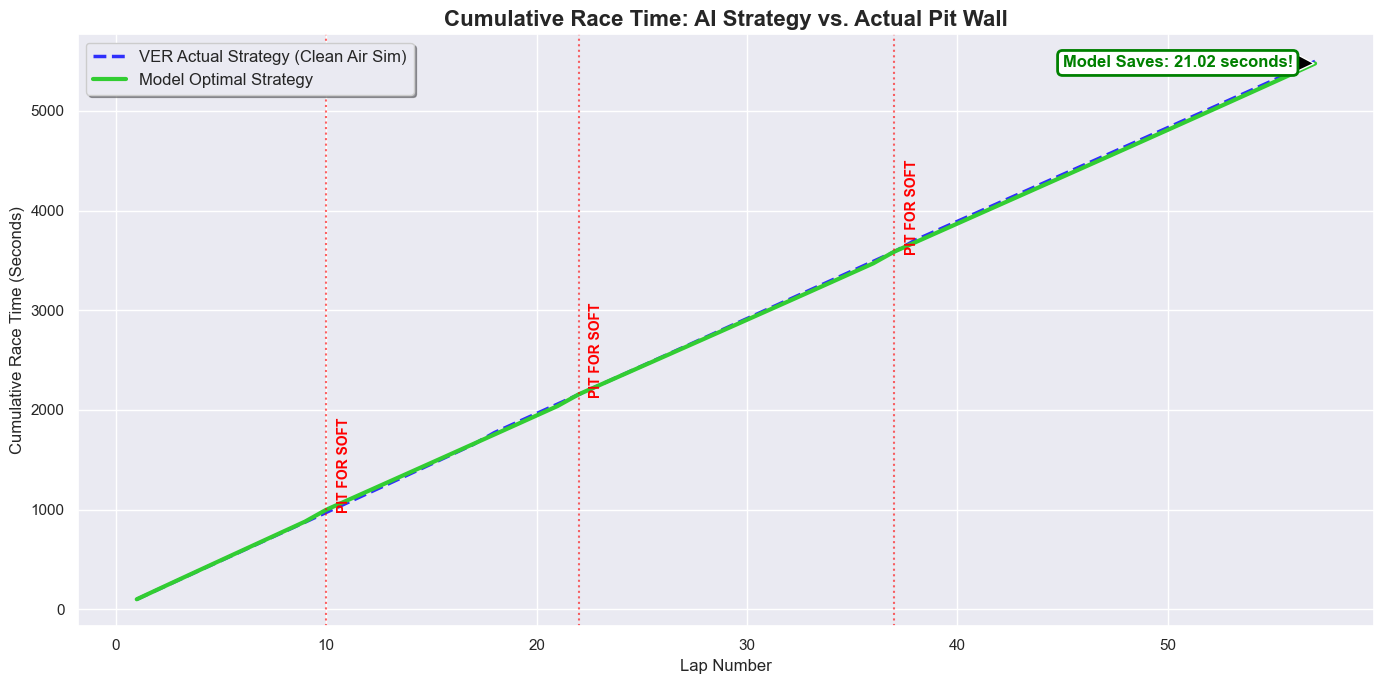

In [ ]:
print("\nComparison Graph")

def simulate_strategy_timeline(strategy_sequence, start_tire):
    cumulative_times = []
    current_time = 0.0
    current_tire = start_tire
    tire_age = 1

    for lap, action in strategy_sequence:
        if "PIT FOR" in action:
            current_time += PIT_LOSS # Add pit lane penalty
            current_tire = action.replace("PIT FOR ", "").strip() # Parse new tire
            tire_age = 1 # Reset tire age
            lap_time = predict_lap_time(lap, tire_age, current_tire)
            current_time += lap_time
            cumulative_times.append(current_time)
            tire_age += 1
        else:

            lap_time = predict_lap_time(lap, tire_age, current_tire)
            current_time += lap_time
            cumulative_times.append(current_time)
            tire_age += 1
            
    return cumulative_times

# 2. Get the timeline for your AI's optimal strategy
dp_cumulative_timeline = simulate_strategy_timeline(winning_strategy, starting_tire)

# eRconstruct Verstappen's ACTUAL 2024 Bahrain Strategy
#Started on SOFT, pitted Lap 18 for HARD, pitted Lap 38 for SOFT
ver_actual_strategy = []
current_tire = "SOFT"
for lap in range(1, TOTAL_LAPS + 1):
    if lap == 18:
        ver_actual_strategy.append((lap, "PIT FOR HARD"))
        current_tire = "HARD"
    elif lap == 38:
        ver_actual_strategy.append((lap, "PIT FOR SOFT"))
        current_tire = "SOFT"
    else:
        ver_actual_strategy.append((lap, f"STAY OUT ({current_tire})"))

ver_cumulative_timeline = simulate_strategy_timeline(ver_actual_strategy, "SOFT")

sns.set_theme(style="darkgrid")
plt.figure(figsize=(14, 7))

laps_x = range(1, TOTAL_LAPS + 1)


plt.plot(laps_x, ver_cumulative_timeline, label="VER Actual Strategy (Clean Air Sim)", color='blue', linestyle='--', linewidth=2.5, alpha=0.8)
plt.plot(laps_x, dp_cumulative_timeline, label="Model Optimal Strategy", color='#32CD32', linewidth=3)

for lap, action in winning_strategy:
    if "PIT FOR" in action:
        plt.axvline(x=lap, color='red', linestyle=':', alpha=0.6)
        plt.text(lap + 0.5, dp_cumulative_timeline[lap-1] - 5, action, rotation=90, color='red', fontsize=10, fontweight='bold')

plt.title('Cumulative Race Time: Model Strategy vs. Actual Pit Wall', fontsize=16, fontweight='bold')
plt.xlabel('Lap Number', fontsize=12)
plt.ylabel('Cumulative Race Time (Seconds)', fontsize=12)
plt.legend(loc='upper left', shadow=True, fontsize=12)

# Calculate theoretical delta
theoretical_delta = ver_cumulative_timeline[-1] - dp_cumulative_timeline[-1]
plt.annotate(f"Model Saves: {theoretical_delta:.2f} seconds!", 
             xy=(57, dp_cumulative_timeline[-1]), 
             xytext=(45, dp_cumulative_timeline[-1] - 40),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold', color='green',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", lw=2))

plt.tight_layout()
plt.show()